In [1]:
import pickle
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

run = pickle.loads(Path(".run.pkl").read_bytes())
card, ev, constants = run["card"], run["evidence"], run["constants"]
gates = {g["number"]: g for g in run["gates"]}
pd.set_option("display.max_colwidth", None)
plt.rcParams.update({"figure.figsize": (9, 3), "axes.spines.top": False, "axes.spines.right": False,
                     "font.size": 9, "axes.titlesize": 10})
INK, GREY, MARK = "#1f4e79", "#a6a6a6", "#c0504d"


def text(value):
    return " ".join(str(value).split()) if value else "—"


def shown(value):
    if value is None:
        return "—"
    if isinstance(value, (list, tuple)):
        return "; ".join(map(str, value)) or "none"
    if isinstance(value, float):
        return float(f"{value:.4g}")
    return value


def table(figures):
    display(pd.Series({k: shown(v) for k, v in figures.items()}, dtype=object).to_frame().T.set_index(pd.Index([""])))


def gate(number):
    g = gates[number]
    reason = g["reason"].removeprefix("not computed: ")
    word = {True: "Passes", False: "Fails", None: "Not computed"}[g["passed"]]
    display(Markdown(f"**{word}**: {reason.rstrip('.')}."))
    if g["figures"]:
        table(g["figures"])


failed = run["failed"]
headline = ("passes gates 1 to 7" if failed is None
            else f"stops at gate {failed}, {gates[failed]['name'].lower()}: {gates[failed]['reason']}")
display(Markdown(f"# {card['id']}\n\nTheory **{card.get('theory', '—')}**. The battery's verdict: "
                 f"the strategy {headline}."))

# TM-038-01-trend-bought-at-its-dips

Theory **TM-038**. The battery's verdict: the strategy stops at gate 3, significance: beats 87.4% of its shifted placebos, fewer than 90%.

## Thesis

In [2]:
prediction = card.get("prediction") or {}
if isinstance(prediction, dict):
    prediction = ", ".join(f"{k}: {v}" for k, v in prediction.items())
display(Markdown(f"**Mechanism.** {text(card.get('mechanism'))}\n\n"
                 f"**Prediction.** {text(prediction)}\n\n"
                 f"**What would refute it.** {text(card.get('refuted_if'))}\n\n"
                 f"**Horizon.** {text(card.get('horizon'))}"))

**Mechanism.** A strategy's profitability moves in cycles with the capital that follows it: flows chase its past performance, crowd it after success and leave it after losses, and its returns revive once the capital has left. Trend following's own returns therefore revert: the lab's trend rule earns more, at the same exposure to its funds, in the months after its own losing stretch than in the months after a winning one.

**Prediction.** sign: positive (the trend rule's months after its own losing stretch earn more over the bill, at the same exposure to the seven funds, than its months after a winning stretch), size: a judgment -- about 0.5 to 3.5% a year more, from an autocorrelation of the book's hedged monthly returns of about -0.02 to -0.05 at each of five lags (Greyserman and Kaminski's typical programme at -0.1, whether by lag or summed they do not say, their evidence at lags of up to five months) on the hedged volatility of about 5.2% a year that TM-017-01's published alpha and appraisal ratio give, widened for the transfer from long-short programmes to a long-only book; the rule's alpha over the seven funds in equal parts about 0 to 2% a year, its return below the book's held in full, as Greyserman and Kaminski's table gives at such a Sharpe ratio and autocorrelation; the base expected to fail gates 3 and 4, likely gate 6 on SPY's share of the profit (TM-017-01's 33%), possibly gates 2 and 5

**What would refute it.** Judged before costs, on the market's closes, over the in-sample months from the first target whose 105 sessions before it all fall on or after the session of the book's first holding, the first session of July 2006, to December 2022, the last month ending at the close of 2022-12-30, the 198 months each from the close of a target's session to the close of the next target's session: the book's return over the month held in full (k = 1), less the bill's over the same sessions, regressed by ordinary least squares on an indicator of the dip state at the target (dip 105) and on the return less the bill's of the seven funds held in equal parts from the same closes, the funds trading at the target, with standard errors robust to heteroskedasticity, the t statistic computed apart from the battery. The theory is refuted in this form if the indicator's t statistic is -0.35 or below: the trend rule no better after its own losing stretch than after a winning one. Between, short of passing gates 1 to 7, not proven, not refuted; a base that passes gates 1 to 7 while the clause refutes leaves the theory refuted in this form. Of TM-038's refutation criteria the second is graded, in its own-performance form, both of its sides by the one contrast; the first, the regime form, is TM-018's, read by TM-018-01, and its capital form is not held; the third is not graded. TM-018-01's equity-crisis months and its divergent months, whose edge of TM-017-01's rule it published, each state apart: if 90% or more of the state's months among the 198 fall in one of the dip and no-dip sets, they leave the graded sample, the graded months fewer by as many, and the clause with them is reported; otherwise they stay, disclosed, and the clause without them is reported. TM-017-01's and TM-018-01's published years and blocks, and the registry's monthly hedged returns of TM-017-01, TM-018-01 and TM-047-01, from which nothing was computed, stay, disclosed. Reported, not graded: the same regression for the variant, dip 252, over its own 190 months from March 2007; the same regression without the seven funds as a regressor, and with a beta for each state; the share of months in a dip, the base's average scale, and the autocorrelations at lags 1 to 5, and their sum, of the book's hedged monthly returns; where TM-018-01's crisis and divergent months fall; the clause over the months of 2006 to 2013, over those of 2014 to 2022, and over the holdout, 2023 to 2025; the Sharpe ratios before costs of the base and of the book held in full; the alpha and the return of the book held constantly at the base's average scale, against the base's; python -m lab.compare against TM-017-01; the base's alpha before and after costs, and the neighbours' and the one-day-late rule's alphas and appraisal ratios.

**Horizon.** months

## Data

In [3]:
x = ev.get("excess")
start, end = constants["in sample"]
cannot_run = gates[1]["reason"].startswith("the strategy cannot run")
broke = gates[1]["reason"].startswith("cannot be computed: ")        # the runs every gate judges broke
evaluated = (f"evaluated from the first session the strategy holds an asset, {x.index[0].date()}, to "
             f"{x.index[-1].date()}" if x is not None and len(x)
             else "not evaluated: the strategy cannot run" if cannot_run
             else f"not evaluated: the runs every gate judges broke ({gates[1]['reason'].split(': ', 1)[1]})"
             if broke else "not evaluated: nothing was held")
display(Markdown(
    f"Daily closes adjusted for dividends and splits, snapshot **{run['snapshot']}**. "
    f"Universe: {', '.join(card['universe'])}. In-sample {start} to {end}, {evaluated}; "
    f"holdout {' to '.join(constants['holdout'])}, opened once, at gate 7. "
    f"Returns are above the Treasury-bill rate, net of costs."))

Daily closes adjusted for dividends and splits, snapshot **2026-09-22+2026-09-23**. Universe: SPY, EFA, EEM, IEF, TLT, GLD, DBC. In-sample 2005-01-01 to 2022-12-31, evaluated from the first session the strategy holds an asset, 2006-02-02, to 2022-12-30; holdout 2023-01-01 to 2025-12-31, opened once, at gate 7. Returns are above the Treasury-bill rate, net of costs.

## Signal

The book is TM-017-01's rule: on the first session of each month, each fund whose return over the past 252 sessions, read up to the session before, beats the Treasury bill's over the same sessions and that trades holds a seventh of the portfolio, the rest in cash; its weights drift with the funds' closes and the bill until the next target. The book's daily excess return is the sum over the funds of each drifting weight times the fund's return less the bill's, before costs, and zero before the book's first holding. The book is in a dip when the sum of its daily excess returns over the last dip sessions to the session before the target is below zero. On the first session of each month the portfolio holds the book's weights at a scale k, 1 when the book is in a dip and 0.5 otherwise, the rest in cash; while fewer than dip sessions precede the target, k is 0.5. Everything is read up to the session before; targets are traded at the close.

- **dip**: sessions of the book's own excess returns whose sum decides the dip, the five months of the Newedge study's negative autocorrelation in the base and the book's own lookback, a choice of the lab's, in the variant

,dip
base,105
variant 1,252


Parameter neighbours, moved one at a time for gate 6: dip at ±25%: 79, 131; dip at ±50%: 53, 158.

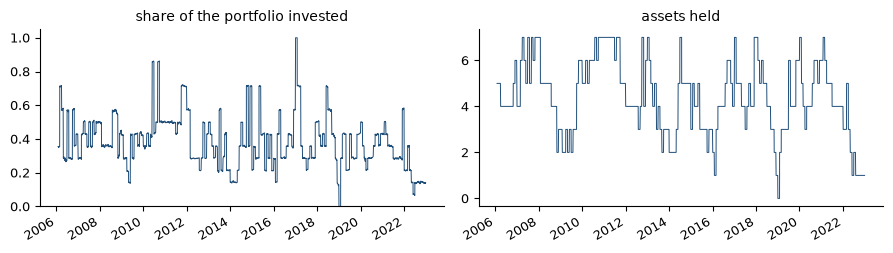

In [4]:
display(Markdown(text(card.get("signal"))))
parameters = card.get("parameters") or {}
if parameters:
    display(Markdown("\n".join(f"- **{k}**: {text(v)}" for k, v in parameters.items())))
variants = pd.DataFrame(card["variants"], index=["base"] + [f"variant {k}" for k in range(1, len(card["variants"]))])
display(variants)
neighbours = card.get("neighbours") or {}
if neighbours:
    display(Markdown("Parameter neighbours, moved one at a time for gate 6: "
                     + "; ".join(f"{p} at ±{step}%: {', '.join(map(str, values))}"
                                 for p, steps in neighbours.items() for step, values in steps.items()) + "."))
if "exposure" in ev:
    fig, (a, b) = plt.subplots(1, 2, figsize=(9, 2.6))
    ev["exposure"].plot(ax=a, color=INK, linewidth=0.7)
    a.set_title("share of the portfolio invested")
    a.set_ylim(0, 1.05)
    ev["assets held"].plot(ax=b, color=INK, linewidth=0.7)
    b.set_title("assets held")
    for axis in (a, b):
        axis.set_xlabel("")
    plt.tight_layout()

## Equity against the benchmark

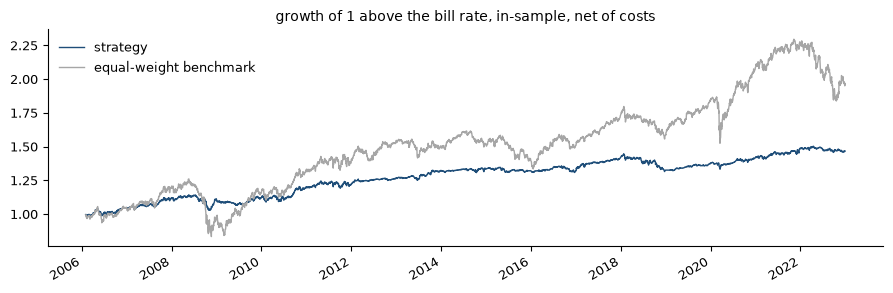

In [5]:
if x is not None and len(x):
    b = ev["benchmark excess"]
    fig, ax = plt.subplots()
    (1 + x).cumprod().plot(ax=ax, color=INK, linewidth=1, label="strategy")
    (1 + b).cumprod().plot(ax=ax, color=GREY, linewidth=1, label="equal-weight benchmark")
    ax.set_title("growth of 1 above the bill rate, in-sample, net of costs")
    ax.set_xlabel("")
    ax.legend(frameon=False)
    plt.tight_layout()
else:
    display(Markdown("The strategy cannot run: there is no equity to draw." if cannot_run
                     else "The runs every gate judges broke: there is no equity to draw." if broke
                     else "Nothing was held in-sample: there is no equity to draw."))

## Gate 1 · Hygiene

Protects against look-ahead, bad data and too little evidence.

**Passes**: no look-ahead on 200 dates, 136 decisions over 16.9 years.

,dates checked,look-ahead breaks,same-day breaks,memory,memory dates checked,memory breaks,data problems,clustered decisions,years in-sample,years needed
,200,0,0,530,100,0,none,136,16.9,5


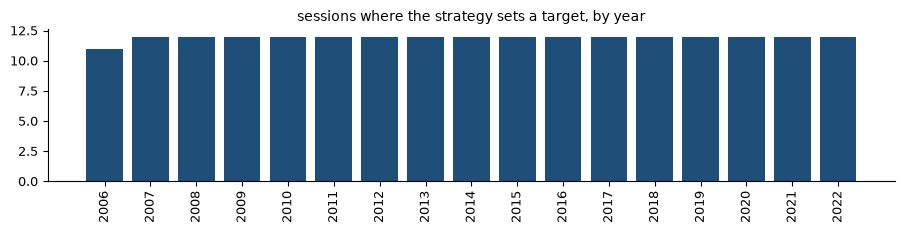

In [6]:
gate(1)
days = ev.get("target days")
if days is not None and len(days):
    per_year = pd.Series(1, index=days).groupby(days.year).sum()
    fig, ax = plt.subplots(figsize=(9, 2.4))
    ax.bar(per_year.index.astype(str), per_year, color=INK)
    breaks = sorted({d.year for variant in ev["timing breaks"].values() for kind in variant.values() for d in kind})
    for year in breaks:
        ax.bar(str(year), per_year.get(year, 0), color=MARK)
    ax.set_title("sessions where the strategy sets a target, by year" + ("; red: a timing break" if breaks else ""))
    ax.tick_params(axis="x", rotation=90)
    plt.tight_layout()

## Gate 2 · Economic edge

Protects against an edge explained by costs or by market exposure.

**Passes**: Sharpe 0.54 against the benchmark's 0.41, alpha 1.23%, 0.52 at twice the costs.

,Sharpe,benchmark Sharpe,alpha,Sharpe at 2x costs,alpha at 2x costs,gross Sharpe,costs a year,costs in Sharpe units
,0.5419,0.4069,0.01225,0.5246,0.01155,0.5591,0.000755,0.01733


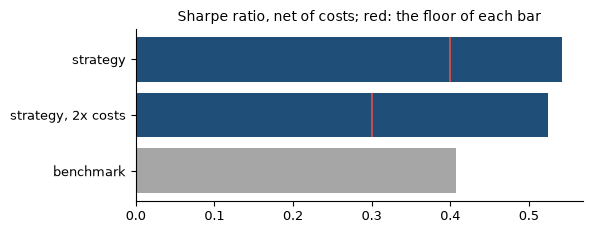

In [7]:
gate(2)
f = gates[2]["figures"]
if f:
    floors = constants["floors"]
    rows = [("benchmark", f["benchmark Sharpe"], GREY, None),
            ("strategy, 2x costs", f["Sharpe at 2x costs"], INK, floors["Sharpe at 2x costs"]),
            ("strategy", f["Sharpe"], INK, floors["Sharpe"])]
    fig, ax = plt.subplots(figsize=(6, 2.4))
    for y, (label, value, colour, floor) in enumerate(rows):
        ax.barh(y, value, color=colour)
        if floor is not None:
            ax.vlines(floor, y - 0.4, y + 0.4, color=MARK, linewidth=1.5)
    ax.set_yticks(range(len(rows)), [r[0] for r in rows])
    ax.set_title("Sharpe ratio, net of costs; red: the floor of each bar")
    plt.tight_layout()

## Gate 3 · Significance

Protects against luck, and against being paid only for being invested. A strategy that holds nearly every asset that trades is close to its benchmark: its placebos differ from it by little, details of the path decide its rank, and gates 2 and 4 judge it.

**Fails**: beats 87.4% of its shifted placebos, fewer than 90%.

,PSR,placebo sessions,placebos,placebos beaten
,0.9918,4259,1000,0.874


Assets that start trading after 2006-02-01: DBC. A placebo shifts their weights only between days when they trade. Where it draws from a day before their start, it keeps their own weights; where it draws from a day after their start onto a day before it, the share it cannot hold yet takes the strategy's own weights of that day, and with them its timing: skill that lies before a late start is judged against placebos that share it, and is found less often. Where the strategy holds none of the assets shifted that day, the shifted weights take that share instead.

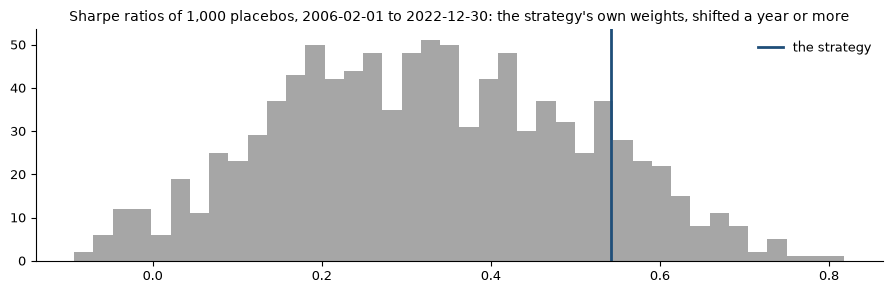

In [8]:
gate(3)
if "placebos" in ev:
    fig, ax = plt.subplots()
    ax.hist(ev["placebos"], bins=40, color=GREY)
    ax.axvline(ev["placebo own Sharpe"], color=INK, linewidth=2, label="the strategy")
    first, last = (d.date() for d in ev["placebo window"])
    ax.set_title(f"Sharpe ratios of {len(ev['placebos']):,} placebos, {first} to {last}: the strategy's own weights, "
                 f"shifted a year or more")
    ax.legend(frameon=False)
    plt.tight_layout()
    if ev.get("placebo late assets"):
        display(Markdown(f"Assets that start trading after {first}: {', '.join(ev['placebo late assets'])}. A placebo "
                         f"shifts their weights only between days when they trade. Where it draws from a day before their "
                         f"start, it keeps their own weights; where it draws from a day after their start onto a day before "
                         f"it, the share it cannot hold yet takes the strategy's own weights of that day, and with them its "
                         f"timing: skill that lies before a late start is judged against placebos that share it, and is "
                         f"found less often. Where the strategy holds none of the assets shifted that day, the shifted "
                         f"weights take that share instead."))

## Gate 4 · Multiple testing

Protects against the best of many tries: the edge, hedged of the benchmark, deflated by every trial the registry holds.

**Fails**: DSR 0.212 below 0.9 over 61 effective trials.

,trials,effective trials,appraisal ratio,Sharpe expected by luck,DSR
,68,61,0.3662,0.6191,0.2121


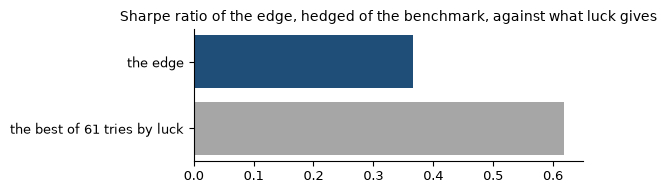

In [9]:
gate(4)
f = gates[4]["figures"]
if f and "appraisal ratio" in f:
    fig, ax = plt.subplots(figsize=(6, 2.0))
    ax.barh([0, 1], [f["Sharpe expected by luck"], f["appraisal ratio"]], color=[GREY, INK])
    tries = f["effective trials"]
    ax.set_yticks([0, 1], [f"the best of {tries} {'try' if tries == 1 else 'tries'} by luck", "the edge"])
    ax.set_title("Sharpe ratio of the edge, hedged of the benchmark, against what luck gives")
    plt.tight_layout()

## Gate 5 · Stability

Protects against an edge that lives in one variant or one episode.

**Fails**: the blend of the variants fails gate 4.

,blend passes gate 2,blend passes gate 3,blend passes gate 4,worst variant Sharpe,positive blocks,best year,alpha without the best year
,True,True,False,0.5419,4,2013,0.01001


The blend of the variants: gate 4, DSR 0.269 below 0.9 over 61 effective trials.

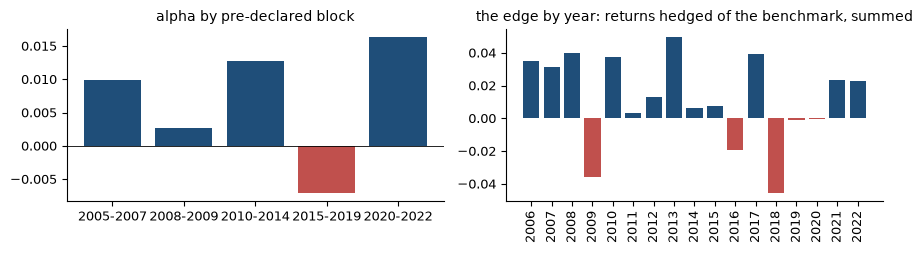

In [10]:
gate(5)
if "blocks" in ev:
    fig, (a, c) = plt.subplots(1, 2, figsize=(9, 2.6))
    blocks = pd.Series({k: (v if v is not None else np.nan) for k, v in ev["blocks"].items()})
    a.bar(blocks.index, blocks.fillna(0), color=[INK if v > 0 else MARK for v in blocks.fillna(0)])
    a.set_title("alpha by pre-declared block")
    a.axhline(0, color="black", linewidth=0.6)
    by_year = ev["edge by year"]
    c.bar(by_year.index.astype(str), by_year, color=[INK if v > 0 else MARK for v in by_year])
    c.set_title("the edge by year: returns hedged of the benchmark, summed")
    c.tick_params(axis="x", rotation=90)
    plt.tight_layout()
failed_blend = {n: reason for n, reason in ev.get("blend", {}).items() if gates[5]["figures"].get(f"blend passes gate {n}") is False}
if failed_blend:
    display(Markdown("The blend of the variants: " + "; ".join(f"gate {n}, {r}" for n, r in failed_blend.items()) + "."))

## Gate 6 · Robustness

Protects against a peak, one asset, timing too tight and a clone.

**Fails**: SPY carries 33% of the P&L, more than 30%.

,neighbour median ratio,lowest ±25% ratio,neighbours that hold the base,worst cluster out,worst cluster out ratio,largest P&L share,asset with the largest share,one day late ratio,highest correlation with a survivor,survivor most correlated
,1.046,0.8545,none,bonds,0.7147,0.3315,SPY,1.015,—,—


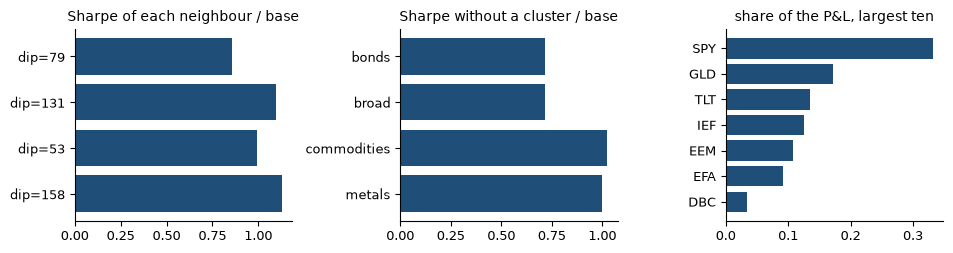

In [11]:
gate(6)
panels = [(k, ev.get(k)) for k in ("neighbours", "clusters out", "P&L shares") if ev.get(k) is not None and len(ev.get(k))]
if panels:
    fig, axes = plt.subplots(1, len(panels), figsize=(3.2 * len(panels), 2.6))
    for axis, (name, values) in zip(np.atleast_1d(axes), panels):
        values = pd.Series(values).head(10)
        axis.barh(values.index.astype(str), values, color=INK)
        axis.set_title({"neighbours": "Sharpe of each neighbour / base", "clusters out": "Sharpe without a cluster / base",
                        "P&L shares": "share of the P&L, largest ten"}[name])
        axis.invert_yaxis()
    plt.tight_layout()
if ev.get("without bitcoin"):
    display(Markdown("Without bitcoin, gate 2's figures:"))
    table(ev["without bitcoin"])

## Gate 7 · Sealed holdout

Protects against bugs and large decay, on years kept aside and opened once.

**Passes**: holdout Sharpe 0.72 and alpha -0.25%, both above the in-sample 10th percentile.

,holdout Sharpe,Sharpe floor,holdout alpha,alpha floor,variants rewritten,dates checked,look-ahead breaks,same-day breaks,data problems
,0.7161,-0.2003,-0.002477,-0.01332,0,40,0,0,none


Red: the 10th percentile of the in-sample paths, the floor; blue: the holdout.

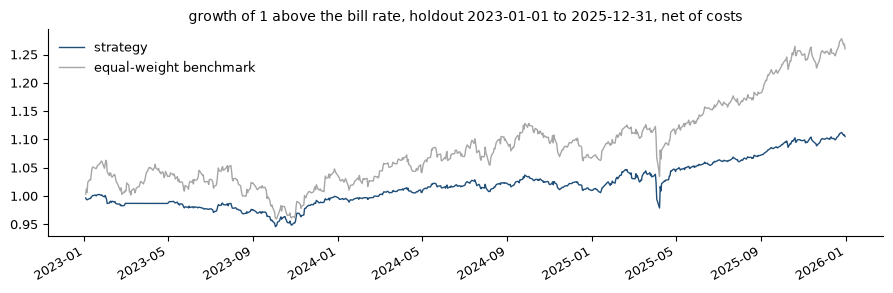

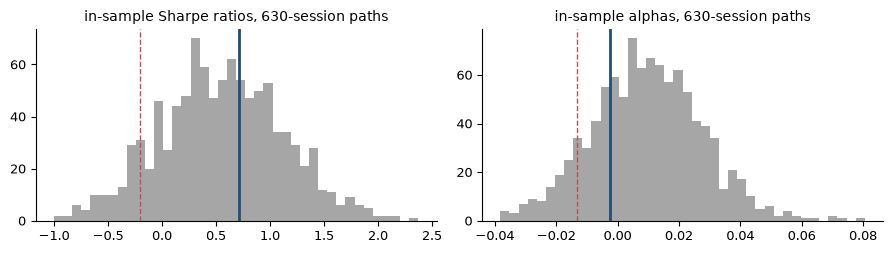

In [12]:
gate(7)
f = gates[7]["figures"]
if "holdout excess" in ev and len(ev["holdout excess"]):
    fig, ax = plt.subplots()
    (1 + ev["holdout excess"]).cumprod().plot(ax=ax, color=INK, linewidth=1, label="strategy")
    (1 + ev["holdout benchmark excess"]).cumprod().plot(ax=ax, color=GREY, linewidth=1, label="equal-weight benchmark")
    ax.set_title(f"growth of 1 above the bill rate, holdout {' to '.join(constants['holdout'])}, net of costs")
    ax.set_xlabel("")
    ax.legend(frameon=False)
    plt.tight_layout()
if "bootstrap" in ev and f:
    pct = constants["percentile"]
    fig, (a, c) = plt.subplots(1, 2, figsize=(9, 2.6))
    for axis, key, mark, label in ((a, "Sharpe", "holdout Sharpe", "Sharpe ratio"), (c, "alpha", "holdout alpha", "alpha")):
        axis.hist(ev["bootstrap"][key], bins=40, color=GREY)
        axis.axvline(np.percentile(ev["bootstrap"][key], pct), color=MARK, linestyle="--", linewidth=1)
        axis.axvline(f[mark], color=INK, linewidth=2)
        axis.set_title(f"in-sample {label}s, {constants['window']}-session paths")
    plt.tight_layout()
    display(Markdown(f"Red: the {pct}th percentile of the in-sample paths, the floor; blue: the holdout."))

## Verdict

In [13]:
table = pd.DataFrame([{"gate": f"{g['number']} · {g['name']}",
                       "result": {True: "passes", False: "fails", None: "not computed"}[g["passed"]],
                       "reason": g["reason"].removeprefix("not computed: ")} for g in run["gates"]]).set_index("gate")
display(table)
display(Markdown(f"Thresholds, version {run['thresholds']}. What the verdict means for the theory, and what was "
                 f"learned, is written in [verdict.md](verdict.md)."))

,result,reason
gate,,
1 · Hygiene,passes,"no look-ahead on 200 dates, 136 decisions over 16.9 years"
2 · Economic edge,passes,"Sharpe 0.54 against the benchmark's 0.41, alpha 1.23%, 0.52 at twice the costs"
3 · Significance,fails,"beats 87.4% of its shifted placebos, fewer than 90%"
4 · Multiple testing,fails,DSR 0.212 below 0.9 over 61 effective trials
5 · Stability,fails,the blend of the variants fails gate 4
6 · Robustness,fails,"SPY carries 33% of the P&L, more than 30%"
7 · Sealed holdout,passes,"holdout Sharpe 0.72 and alpha -0.25%, both above the in-sample 10th percentile"


Thresholds, version 4. What the verdict means for the theory, and what was learned, is written in [verdict.md](verdict.md).